/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


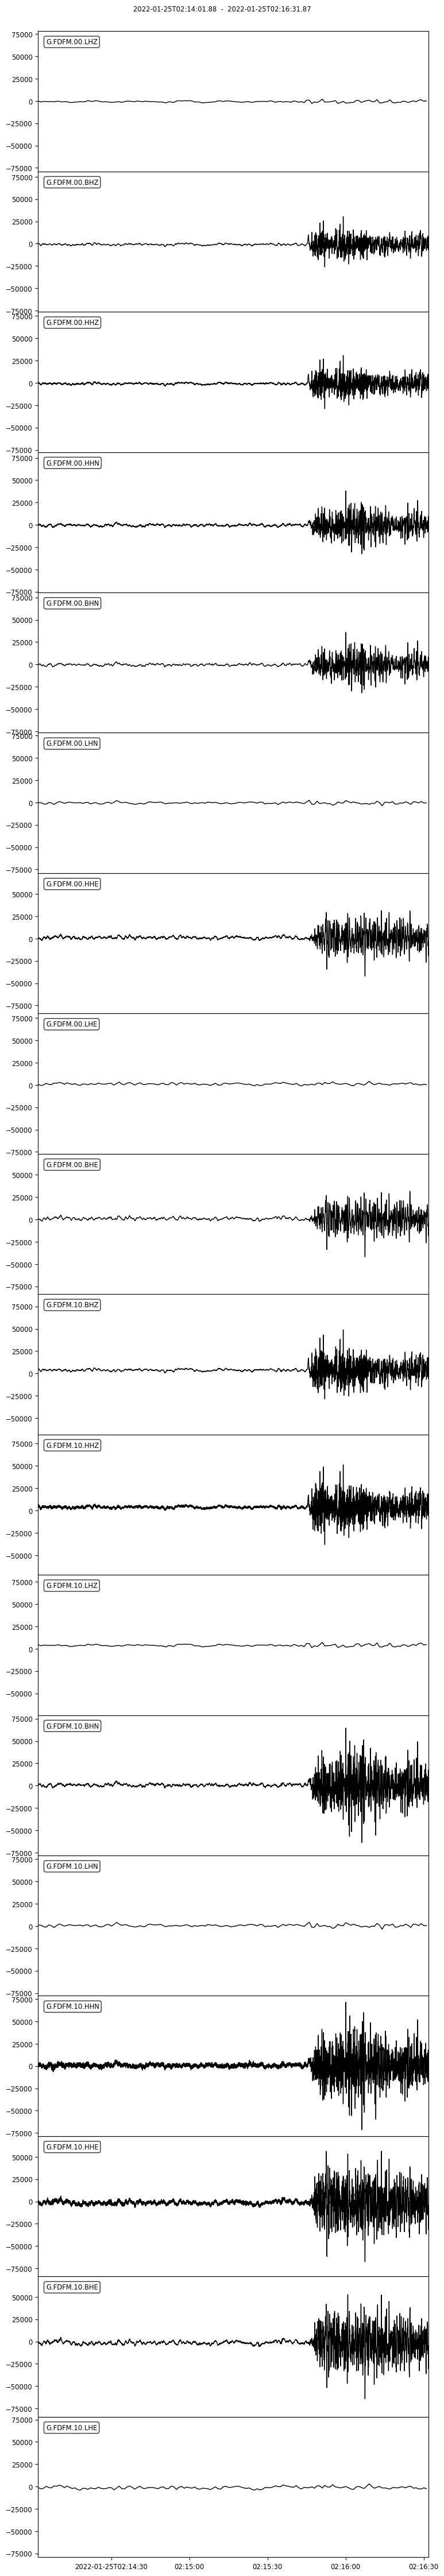

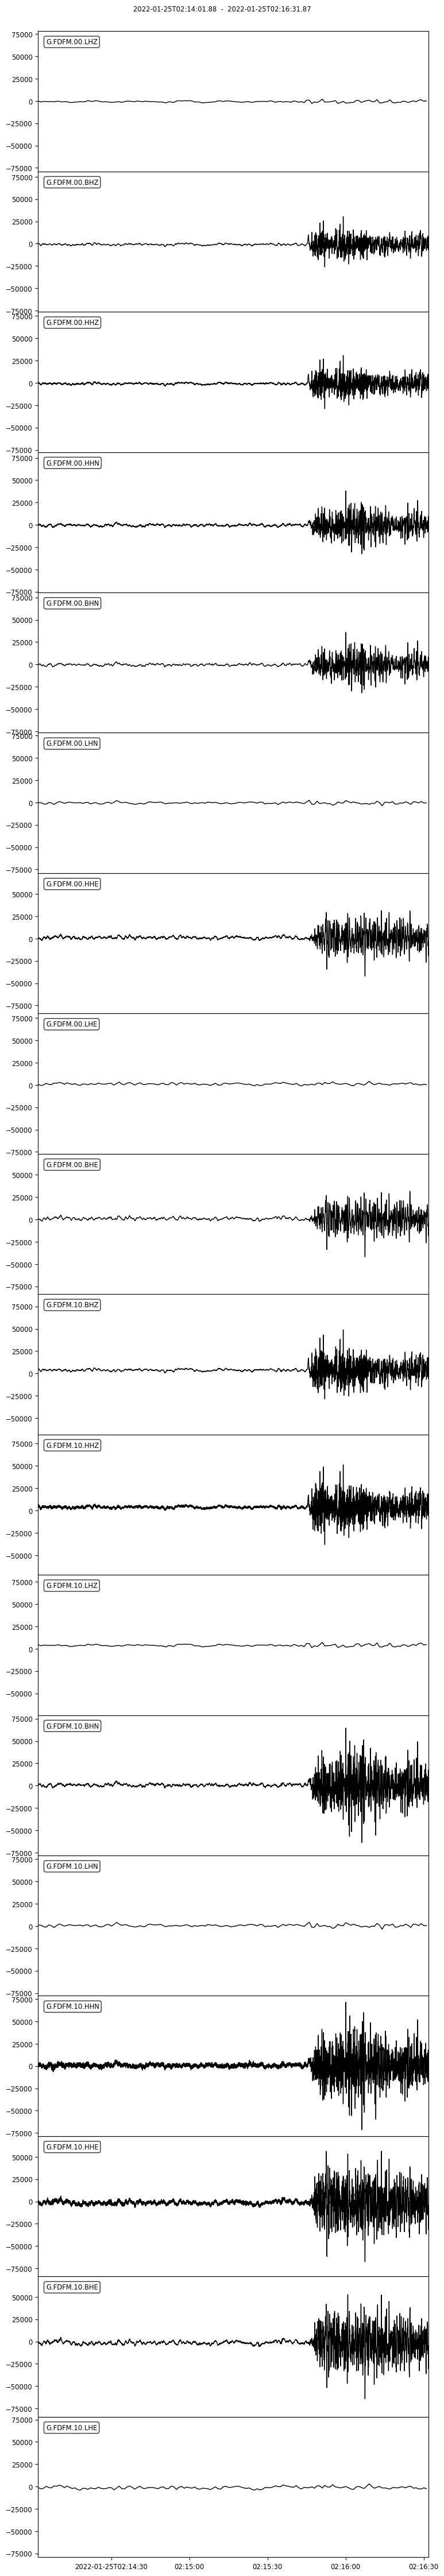

In [2]:
from obspy import read
import matplotlib.pyplot as plt

st = read('/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c/G_FDFM_20220125_021431.mseed')
st.plot()  # Ini akan menampilkan bentuk gelombang

In [3]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

client = Client("IRIS")

inventory = client.get_stations(
    network="CU",
    station="GRGR",
    starttime=UTCDateTime("2026-06-28T08:45:00"),
    endtime=UTCDateTime("2026-06-28T08:50:00"),
    level="response"
)
print(inventory)

/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


Inventory created at 2026-07-15T03:23:02.201800Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			CU
		Stations (1):
			CU.GRGR (Grenville, Grenada)
		Channels (32):
			CU.GRGR.00.BHZ, CU.GRGR.00.BH1, CU.GRGR.00.BH2, CU.GRGR.00.HHZ, 
			CU.GRGR.00.HH1, CU.GRGR.00.HH2, CU.GRGR.00.LHZ, CU.GRGR.00.LH1, 
			CU.GRGR.00.LH2, CU.GRGR.00.VHZ, CU.GRGR.00.VH1, CU.GRGR.00.VH2, 
			CU.GRGR.00.VMU, CU.GRGR.00.VMV, CU.GRGR.00.VMW, CU.GRGR.20.HNZ, 
			CU.GRGR.20.HN1, CU.GRGR.20.HN2, CU.GRGR.20.LNZ, CU.GRGR.20.LN1, 
			CU.GRGR.20.LN2, CU.GRGR.30.LDO, CU.GRGR.31.LDO, CU.GRGR.32.BDF, 
			CU.GRGR.50.LDO, CU.GRGR.50.LES, CU.GRGR.50.LIO, CU.GRGR.50.LKO, 
			CU.GRGR.50.LRH, CU.GRGR.50.LRI, CU.GRGR.50.LWD, CU.GRGR.50.LWS


In [4]:
import numpy as np
data = st[0].data
print(f"Mean: {np.mean(data)}")
print(f"Std dev: {np.std(data)}")
print(f"Min-max: {np.min(data)} - {np.max(data)}")

Mean: -796.3646666666667
Std dev: 3797.0549522427978
Min-max: -25984 - 30546


In [6]:
from obspy import read
import matplotlib.pyplot as plt

# Baca file Anda
st = read("/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c/G_FDFM_20220125_021431.mseed")

# 1. Hilangkan offset DC (detrend)
st.detrend(type="demean")

# 2. Filter bandpass untuk gelombang P (1–5 Hz)
st.filter(type="bandpass", freqmin=1.0, freqmax=5.0)

# 3. Plot dengan skala yang lebih baik
st.plot(size=(800, 600))

/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (5.0) of bandpass is at or above Nyquist (0.5). Applying a high-pass instead.
  warnings.warn(msg)


ValueError: Selected corner frequency is above Nyquist.

Sampling rate: 20.0 Hz


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


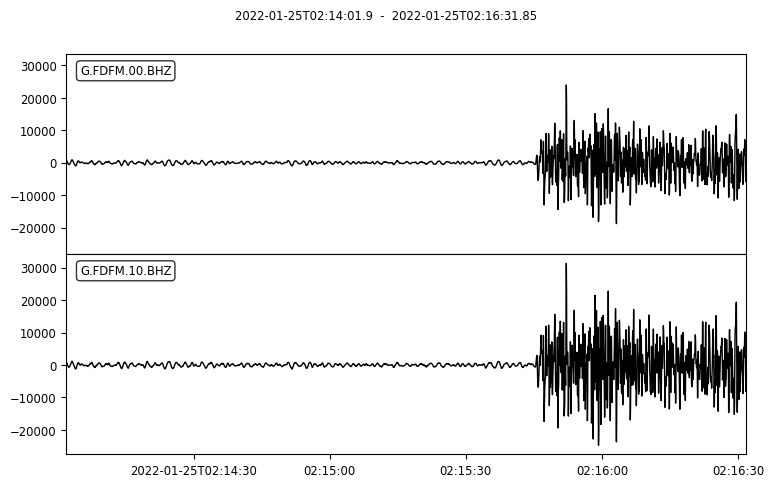

In [7]:
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt

st = read('/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c/G_FDFM_20220125_021431.mseed')

# Pilih BHZ atau HHZ (jika ada)
st_bhz = st.select(channel="BHZ")
if len(st_bhz) == 0:
    st_bhz = st.select(channel="HHZ")

if len(st_bhz) > 0:
    st_bhz.detrend("demean")
    sr = st_bhz[0].stats.sampling_rate
    print(f"Sampling rate: {sr} Hz")
    # Filter bandpass 1–5 Hz jika sr ≥ 10 Hz
    if sr >= 10:
        st_bhz.filter("bandpass", freqmin=0.5, freqmax=min(5.0, sr/2 - 0.1))
    else:
        st_bhz.filter("lowpass", freq=min(0.4, sr/2 - 0.1))
    st_bhz.plot()
else:
    print("Tidak ada channel BHZ/HHZ, gunakan LHZ")
    st_lhz = st.select(channel="LHZ")
    st_lhz.detrend("demean")
    st_lhz.filter("lowpass", freq=0.3)
    st_lhz.plot()

Sampling rate: 20.0 Hz


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


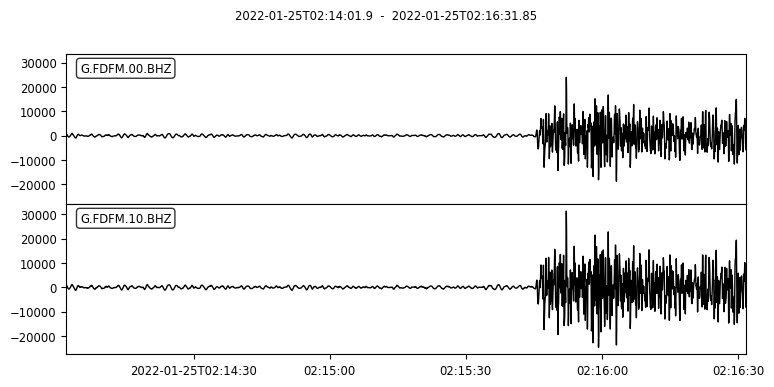

Mean: 0.36205605358339227
Std dev: 3054.853021985106


In [8]:
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt

# Baca file
st = read('/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c/G_FDFM_20220125_021431.mseed')

# Ambil hanya BHZ
st_bhz = st.select(channel="BHZ")

# Periksa apakah BHZ ada
if len(st_bhz) == 0:
    print("BHZ tidak ditemukan, coba channel lain")
    st_bhz = st.select(channel="HHZ")
    if len(st_bhz) == 0:
        st_bhz = st.select(channel="LHZ")

# 1. Hilangkan offset DC
st_bhz.detrend("demean")

# 2. Periksa sampling rate
sr = st_bhz[0].stats.sampling_rate
print(f"Sampling rate: {sr} Hz")

# 3. Filter sesuai sampling rate
if sr >= 10:
    st_bhz.filter("bandpass", freqmin=0.5, freqmax=min(5.0, sr/2 - 0.1))
else:
    # Untuk LHZ (low sampling rate)
    st_bhz.filter("lowpass", freq=min(0.4, sr/2 - 0.1))

# 4. Plot
st_bhz.plot(size=(800, 400))

# 5. Tampilkan statistik setelah preprocessing
print(f"Mean: {st_bhz[0].data.mean()}")
print(f"Std dev: {st_bhz[0].data.std()}")

In [14]:
from obspy import read, UTCDateTime

# 1. Baca file
try:
    st = read('/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c/G_FDFM_20220125_021431.mseed')
except Exception as e:
    print(f"Gagal membaca file: {e}")
    exit()

# 2. Debugging: Cek isi file (Channel apa saja yang tersedia?)
print("Channel yang tersedia di dalam file:")
for tr in st:
    print(f"  - Station: {tr.stats.station}, Channel: {tr.stats.channel}, "
          f"Waktu: {tr.stats.starttime} s/d {tr.stats.endtime}")

# 3. Seleksi channel "BHZ" dengan penanganan error
st_bhz = st.select(channel="BHZ")

if len(st_bhz) == 0:
    print("ERROR: Channel 'BHZ' tidak ditemukan!")
    print("Channel yang tersedia:", set(tr.stats.channel for tr in st))
    # Opsional: jika mau pakai channel lain, ubah di sini
    # Misal: st_bhz = st.select(channel="HHZ") 
    exit()  # Hentikan eksekusi agar tidak lanjut ke plot

# 4. Detrend
st_bhz.detrend("demean")

# 5. Slice waktu
origin = UTCDateTime("2026-06-28T08:46:10")
start = origin - 10
end = origin + 30

# Cek apakah rentang slice valid sebelum melakukan slice
# Ambil referensi trace pertama untuk cek batas waktu
ref_trace = st_bhz[0]
if start < ref_trace.stats.starttime or end > ref_trace.stats.endtime:
    print(f"PERINGATAN: Rentang slice {start} s/d {end} berada di luar jangkauan data.")
    print(f"Data tersedia dari {ref_trace.stats.starttime} s/d {ref_trace.stats.endtime}")
    print("Memotong data sesuai batas yang tersedia...")
    # Potong secara aman dengan start/end yang dibatasi
    st_slice = st_bhz.slice(starttime=max(start, ref_trace.stats.starttime), 
                            endtime=min(end, ref_trace.stats.endtime))
else:
    st_slice = st_bhz.slice(starttime=start, endtime=end)

# 6. Cek apakah hasil slice kosong
if len(st_slice) == 0:
    print("ERROR: Tidak ada data pada rentang waktu tersebut (stream kosong).")
else:
    print(f"Berhasil mengambil data, jumlah trace: {len(st_slice)}")
    # 7. Plot dengan aman
    st_slice.plot(size=(800, 400))

Channel yang tersedia di dalam file:
  - Station: FDFM, Channel: BHZ, Waktu: 2022-01-25T02:14:01.900000Z s/d 2022-01-25T02:16:31.850000Z
  - Station: FDFM, Channel: BHZ, Waktu: 2022-01-25T02:14:01.900000Z s/d 2022-01-25T02:16:31.850000Z
  - Station: FDFM, Channel: BHN, Waktu: 2022-01-25T02:14:01.900000Z s/d 2022-01-25T02:16:31.850000Z
  - Station: FDFM, Channel: BHN, Waktu: 2022-01-25T02:14:01.900000Z s/d 2022-01-25T02:16:31.850000Z
  - Station: FDFM, Channel: BHE, Waktu: 2022-01-25T02:14:01.900000Z s/d 2022-01-25T02:16:31.850000Z
  - Station: FDFM, Channel: BHE, Waktu: 2022-01-25T02:14:01.900000Z s/d 2022-01-25T02:16:31.850000Z
  - Station: FDFM, Channel: HHZ, Waktu: 2022-01-25T02:14:01.880000Z s/d 2022-01-25T02:16:31.870000Z
  - Station: FDFM, Channel: HHZ, Waktu: 2022-01-25T02:14:01.880000Z s/d 2022-01-25T02:16:31.870000Z
  - Station: FDFM, Channel: HHN, Waktu: 2022-01-25T02:14:01.880000Z s/d 2022-01-25T02:16:31.870000Z
  - Station: FDFM, Channel: HHN, Waktu: 2022-01-25T02:14:01.880

ValueError: startime is larger than endtime

In [15]:
sr = st_bhz[0].stats.sampling_rate
print("Sampling rate:", sr)
if sr >= 10:
    st_bhz.filter("bandpass", freqmin=0.5, freqmax=5.0)
else:
    st_bhz.filter("lowpass", freq=0.4)
st_bhz.slice(origin - 10, origin + 30).plot()

Sampling rate: 20.0


IndexError: Empty stream object

In [16]:
st_3comp = st.select(channel="BHZ") + st.select(channel="BHN") + st.select(channel="BHE")
st_3comp.detrend("demean")
st_3comp.filter("bandpass", freqmin=0.5, freqmax=5.0)
st_3comp.slice(origin - 5, origin + 35).plot()

IndexError: Empty stream object